In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("featured_freight.csv")
df['RR DATE'] = pd.to_datetime(df['RR DATE'])
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (1194, 61)
Columns: ['DVSN', 'STTN FROM', 'STTN TO', 'RR NO.', 'RR DATE', 'FNR', 'P/T', 'INVC NO.', 'INVC DATE', 'CMDT', 'CNSR', 'CNSR GSTIN', 'CNSG', 'CNSG GSTIN', 'RLY GSTIN', 'TAX INVCID', 'FREIGHT PAID BY', 'ADVANCE FREIGHT SCHEME', 'ROUND TRIP TRAFFIC', 'CHRG WGHT', 'ACTL WGHT', 'CHRG CLSS', 'RATE(Q)', 'BSC FRGT', 'POL', 'TOTL FRGT(EXCLUDE GST)', 'IGST', 'CGST', 'SGST', 'UGST', 'TOTL GST', 'TDS IGST', 'TDS CGST', 'TDS SGST', 'TDS UGST', 'TOTL TDS', 'TDS REGISTRATION NO.', 'TOTL FRGT(INCLUDE GST)', 'DMRG', 'P/M', 'OTHR CHRG CODE', 'OTHR CHRG AMNT', 'REBATE CODE', 'REBATE AMNT', 'E-PAYID', '_source', 'WEIGHT_DIFF', 'WEIGHT_DIFF_PCT', 'FREIGHT_PER_TONNE', 'GST_RATE_PCT', 'HAS_DEMURRAGE', 'HAS_OTHER_CHARGES', 'ROUTE', 'DAY_OF_WEEK', 'MONTH', 'WEEK', 'CNSR_ENC', 'DVSN_ENC', 'ROUTE_ENC', 'IS_ANOMALY', 'ANOMALY_SCORE']


In [37]:
# ML models only understand numbers, not text
# So we convert CNSR, DVSN, ROUTE to numbers

le_cnsr  = LabelEncoder()
le_dvsn  = LabelEncoder()
le_route = LabelEncoder()

df['CNSR_ENC']  = le_cnsr.fit_transform(df['CNSR'].fillna('Unknown'))
df['DVSN_ENC']  = le_dvsn.fit_transform(df['DVSN'].fillna('Unknown'))
df['ROUTE_ENC'] = le_route.fit_transform(df['ROUTE'].fillna('Unknown'))

print("Encoding done!")
print("Unique consignors:", df['CNSR'].nunique())
print("Unique routes:", df['ROUTE'].nunique())

Encoding done!
Unique consignors: 16
Unique routes: 82


In [38]:
# Features we use to predict freight cost
features = ['CHRG WGHT', 'ACTL WGHT', 'RATE(Q)',
            'CNSR_ENC', 'ROUTE_ENC', 'DVSN_ENC',
            'HAS_DEMURRAGE', 'OTHR CHRG AMNT', 'DAY_OF_WEEK']

target = 'TOTL FRGT(INCLUDE GST)'

X = df[features].fillna(0)
y = df[target]

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

# Linear Regression (simple baseline)
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("\nLinear Regression:")
print("  R² Score:", round(r2_score(y_test, lr_pred), 4))
print("  MAE: ₹", round(mean_absolute_error(y_test, lr_pred), 2))

# Random Forest (better model)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("\nRandom Forest:")
print("  R² Score:", round(r2_score(y_test, rf_pred), 4))
print("  MAE: ₹", round(mean_absolute_error(y_test, rf_pred), 2))

Training rows: 955
Testing rows: 239

Linear Regression:
  R² Score: 0.9461
  MAE: ₹ 361706.78

Random Forest:
  R² Score: 0.9885
  MAE: ₹ 90153.98


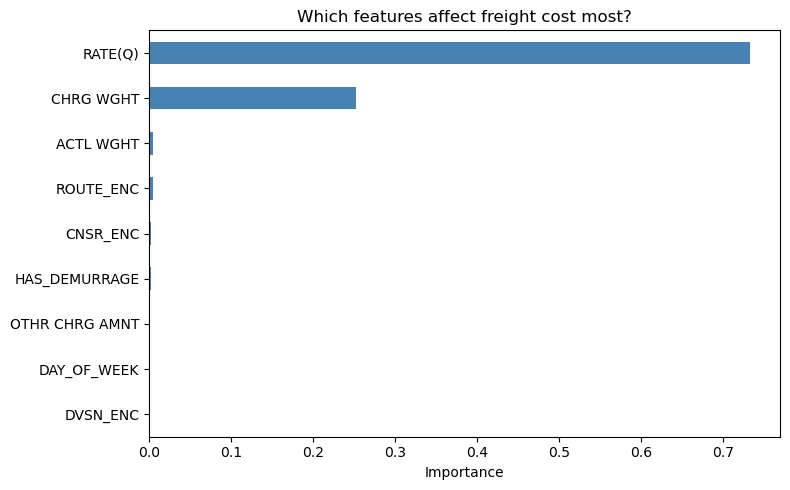

In [39]:
import matplotlib.pyplot as plt

importance = pd.Series(rf.feature_importances_, index=features)
importance.sort_values().plot(kind='barh', figsize=(8,5), color='steelblue')
plt.title('Which features affect freight cost most?')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [40]:
anom_features = ['FREIGHT_PER_TONNE', 'WEIGHT_DIFF_PCT', 'GST_RATE_PCT', 'RATE(Q)']
X_anom = df[anom_features].replace([np.inf, -np.inf], 0).fillna(0)

iso = IsolationForest(contamination=0.05, random_state=42)
df['IS_ANOMALY'] = (iso.fit_predict(X_anom) == -1).astype(int)
df['ANOMALY_SCORE'] = -iso.score_samples(X_anom)

print("Anomalies found:", df['IS_ANOMALY'].sum())
print("\nTop 5 suspicious shipments:")
print(df[df['IS_ANOMALY']==1][['CNSR','ROUTE','CHRG WGHT','FREIGHT_PER_TONNE','ANOMALY_SCORE']]
      .sort_values('ANOMALY_SCORE', ascending=False).head())
# Save updated dataframe with anomaly column
df.to_csv("featured_freight.csv", index=False)
print("Saved with anomaly column!")

Anomalies found: 60

Top 5 suspicious shipments:
     CNSR        ROUTE  CHRG WGHT  FREIGHT_PER_TONNE  ANOMALY_SCORE
575  SAIL  BSCS → DSEY       65.1         410.414747       0.759138
576  SAIL  BSCS → DSEY       65.1         410.414747       0.744224
574  SAIL  BSCS → DSEY       65.1         410.414747       0.733725
996  RINL  VSPS → IISD     4667.0        1930.530319       0.731467
577  SAIL  BSCS → DSEY       65.1         410.414747       0.700549
Saved with anomaly column!


In [41]:
# Group consignors by behaviour
cnsr_stats = df.groupby('CNSR').agg(
    total_freight   = ('TOTL FRGT(INCLUDE GST)', 'sum'),
    avg_freight     = ('TOTL FRGT(INCLUDE GST)', 'mean'),
    shipment_count  = ('RR NO.', 'count'),
    avg_weight      = ('CHRG WGHT', 'mean'),
    demurrage_rate  = ('HAS_DEMURRAGE', 'mean')
).reset_index()

scaler = StandardScaler()
X_cluster = scaler.fit_transform(cnsr_stats[['total_freight','avg_freight','shipment_count','avg_weight','demurrage_rate']])

km = KMeans(n_clusters=3, random_state=42, n_init=10)
cnsr_stats['CLUSTER'] = km.fit_predict(X_cluster)

print("Consignor Clusters:")
for c in sorted(cnsr_stats['CLUSTER'].unique()):
    grp = cnsr_stats[cnsr_stats['CLUSTER']==c]
    print(f"\nCluster {c} — {len(grp)} consignors")
    print("  Members:", list(grp['CNSR']))
    print("  Avg freight: ₹", round(grp['avg_freight'].mean()))
    print("  Avg shipments:", round(grp['shipment_count'].mean()))

Consignor Clusters:

Cluster 0 — 12 consignors
  Members: ['BCPL', 'ECF', 'GUSH', 'JKKS', 'MLDM', 'MWF', 'NMD', 'ORMT', 'RINL', 'RSMM', 'SBTC', 'SSP']
  Avg freight: ₹ 5545433
  Avg shipments: 10

Cluster 1 — 1 consignors
  Members: ['SAIL']
  Avg freight: ₹ 2481976
  Avg shipments: 951

Cluster 2 — 3 consignors
  Members: ['BCCL', 'BSLC', 'CCL']
  Avg freight: ₹ 1458092
  Avg shipments: 41


Days of data we have: 38


12:08:51 - cmdstanpy - INFO - Chain [1] start processing
12:08:52 - cmdstanpy - INFO - Chain [1] done processing


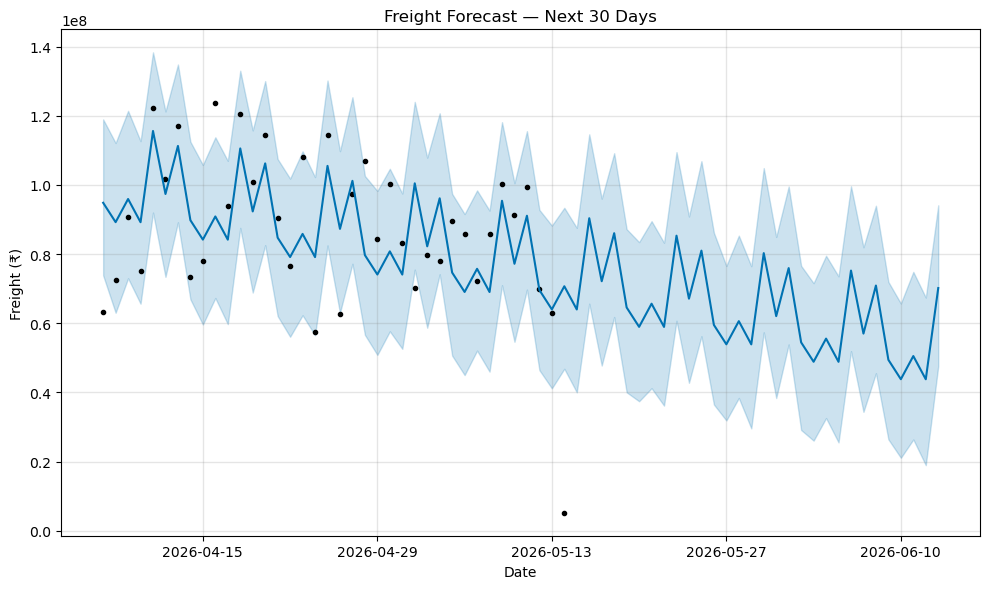


Next 7 days forecast:
      Date  Predicted Freight  Lower Bound  Upper Bound
2026-05-15       6.400792e+07 4.004590e+07 8.761251e+07
2026-05-16       9.038711e+07 6.568256e+07 1.146576e+08
2026-05-17       7.217048e+07 4.778970e+07 9.606011e+07
2026-05-18       8.606642e+07 6.181993e+07 1.091933e+08
2026-05-19       6.458230e+07 4.005005e+07 8.722798e+07
2026-05-20       5.897916e+07 3.746548e+07 8.348237e+07
2026-05-21       6.567275e+07 4.123301e+07 8.954491e+07


In [42]:
from prophet import Prophet

# Prepare data — Prophet needs columns named 'ds' and 'y'
daily = df.groupby('RR DATE')['TOTL FRGT(INCLUDE GST)'].sum().reset_index()
daily.columns = ['ds', 'y']
print("Days of data we have:", len(daily))

# Train Prophet
model = Prophet(daily_seasonality=False, weekly_seasonality=True)
model.fit(daily)

# Predict next 30 days
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# Plot
fig = model.plot(forecast)
plt.title('Freight Forecast — Next 30 Days')
plt.xlabel('Date')
plt.ylabel('Freight (₹)')
plt.tight_layout()
plt.show()

print("\nNext 7 days forecast:")
next7 = forecast[forecast['ds'] > daily['ds'].max()][['ds','yhat','yhat_lower','yhat_upper']].head(7)
next7.columns = ['Date','Predicted Freight','Lower Bound','Upper Bound']
print(next7.to_string(index=False))

In [43]:
import os
os.makedirs("models", exist_ok=True)

joblib.dump(rf,  "models/freight_predictor.pkl")
joblib.dump(iso, "models/anomaly_detector.pkl")
joblib.dump(km,  "models/consignor_clusters.pkl")
joblib.dump({'cnsr': le_cnsr, 'dvsn': le_dvsn, 'route': le_route}, "models/encoders.pkl")
forecast.to_csv("models/forecast.csv", index=False)

print("All models saved in /models folder!")
print(os.listdir("models"))

All models saved in /models folder!
['anomaly_detector.pkl', 'consignor_clusters.pkl', 'encoders.pkl', 'forecast.csv', 'freight_predictor.pkl', 'xgb_predictor.pkl']


In [44]:
print("Rate range in training data:")
print(df['RATE(Q)'].describe())

Rate range in training data:
count    1194.000000
mean      648.587605
std       481.907051
min       185.100000
25%       279.900000
50%       559.600000
75%       797.200000
max      2718.300000
Name: RATE(Q), dtype: float64


In [45]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Same features as Random Forest
features = ['CHRG WGHT', 'ACTL WGHT', 'RATE(Q)',
            'CNSR_ENC', 'ROUTE_ENC', 'DVSN_ENC',
            'HAS_DEMURRAGE', 'OTHR CHRG AMNT', 'DAY_OF_WEEK']

target = 'TOTL FRGT(INCLUDE GST)'

X = df[features].fillna(0)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost model
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    verbosity=0
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("XGBoost Results:")
print(f"  R² Score : {r2_score(y_test, xgb_pred):.4f}")
print(f"  MAE      : ₹{mean_absolute_error(y_test, xgb_pred):,.0f}")

# Compare all three models
rf_pred  = rf.predict(X_test)
lr_pred  = lr.predict(X_test)

print("\nModel Comparison:")
print(f"  Linear Regression : R²={r2_score(y_test, lr_pred):.4f}  MAE=₹{mean_absolute_error(y_test, lr_pred):,.0f}")
print(f"  Random Forest     : R²={r2_score(y_test, rf_pred):.4f}  MAE=₹{mean_absolute_error(y_test, rf_pred):,.0f}")
print(f"  XGBoost           : R²={r2_score(y_test, xgb_pred):.4f}  MAE=₹{mean_absolute_error(y_test, xgb_pred):,.0f}")

XGBoost Results:
  R² Score : 0.9938
  MAE      : ₹75,195

Model Comparison:
  Linear Regression : R²=0.9461  MAE=₹361,707
  Random Forest     : R²=0.9885  MAE=₹90,154
  XGBoost           : R²=0.9938  MAE=₹75,195


In [46]:
import joblib
joblib.dump(xgb, "models/xgb_predictor.pkl")
print("XGBoost model saved!")

XGBoost model saved!


In [59]:
import pandas as pd
df = pd.read_csv("featured_freight.csv")
print(df.columns.tolist())
print(df.head(3))

['DVSN', 'STTN FROM', 'STTN TO', 'RR NO.', 'RR DATE', 'FNR', 'P/T', 'INVC NO.', 'INVC DATE', 'CMDT', 'CNSR', 'CNSR GSTIN', 'CNSG', 'CNSG GSTIN', 'RLY GSTIN', 'TAX INVCID', 'FREIGHT PAID BY', 'ADVANCE FREIGHT SCHEME', 'ROUND TRIP TRAFFIC', 'CHRG WGHT', 'ACTL WGHT', 'CHRG CLSS', 'RATE(Q)', 'BSC FRGT', 'POL', 'TOTL FRGT(EXCLUDE GST)', 'IGST', 'CGST', 'SGST', 'UGST', 'TOTL GST', 'TDS IGST', 'TDS CGST', 'TDS SGST', 'TDS UGST', 'TOTL TDS', 'TDS REGISTRATION NO.', 'TOTL FRGT(INCLUDE GST)', 'DMRG', 'P/M', 'OTHR CHRG CODE', 'OTHR CHRG AMNT', 'REBATE CODE', 'REBATE AMNT', 'E-PAYID', '_source', 'WEIGHT_DIFF', 'WEIGHT_DIFF_PCT', 'FREIGHT_PER_TONNE', 'GST_RATE_PCT', 'HAS_DEMURRAGE', 'HAS_OTHER_CHARGES', 'ROUTE', 'DAY_OF_WEEK', 'MONTH', 'WEEK', 'CNSR_ENC', 'DVSN_ENC', 'ROUTE_ENC', 'IS_ANOMALY', 'ANOMALY_SCORE']
   DVSN STTN FROM STTN TO       RR NO.     RR DATE           FNR P/T  \
0  ADRA      BLSG    BSCS  262003693.0  2026-04-09  2.604080e+10   P   
1  ADRA      BLSG    BSCS  262003694.0  2026-04

In [ ]:
import pandas as pd
df = pd.read_csv("featured_freight.csv")
print(df.columns.tolist())
print(df.head(3))

['DVSN', 'STTN FROM', 'STTN TO', 'RR NO.', 'RR DATE', 'FNR', 'P/T', 'INVC NO.', 'INVC DATE', 'CMDT', 'CNSR', 'CNSR GSTIN', 'CNSG', 'CNSG GSTIN', 'RLY GSTIN', 'TAX INVCID', 'FREIGHT PAID BY', 'ADVANCE FREIGHT SCHEME', 'ROUND TRIP TRAFFIC', 'CHRG WGHT', 'ACTL WGHT', 'CHRG CLSS', 'RATE(Q)', 'BSC FRGT', 'POL', 'TOTL FRGT(EXCLUDE GST)', 'IGST', 'CGST', 'SGST', 'UGST', 'TOTL GST', 'TDS IGST', 'TDS CGST', 'TDS SGST', 'TDS UGST', 'TOTL TDS', 'TDS REGISTRATION NO.', 'TOTL FRGT(INCLUDE GST)', 'DMRG', 'P/M', 'OTHR CHRG CODE', 'OTHR CHRG AMNT', 'REBATE CODE', 'REBATE AMNT', 'E-PAYID', '_source', 'WEIGHT_DIFF', 'WEIGHT_DIFF_PCT', 'FREIGHT_PER_TONNE', 'GST_RATE_PCT', 'HAS_DEMURRAGE', 'HAS_OTHER_CHARGES', 'ROUTE', 'DAY_OF_WEEK', 'MONTH', 'WEEK', 'CNSR_ENC', 'DVSN_ENC', 'ROUTE_ENC', 'IS_ANOMALY', 'ANOMALY_SCORE']
   DVSN STTN FROM STTN TO       RR NO.     RR DATE           FNR P/T  \
0  ADRA      BLSG    BSCS  262003693.0  2026-04-09  2.604080e+10   P   
1  ADRA      BLSG    BSCS  262003694.0  2026-04

In [ ]:
features = ['CHRG WGHT', 'ACTL WGHT', 'RATE(Q)',
            'CNSR_ENC', 'ROUTE_ENC', 'DVSN_ENC',
            'HAS_DEMURRAGE', 'OTHR CHRG AMNT', 'DAY_OF_WEEK']

print(df[features].describe().round(2))

       CHRG WGHT  ACTL WGHT  RATE(Q)  CNSR_ENC  ROUTE_ENC  DVSN_ENC  \
count    1194.00    1194.00  1194.00   1194.00    1194.00   1194.00   
mean     3336.66    3235.51   648.59     11.21      36.37      0.56   
std      1316.15    1280.32   481.91      4.20      21.07      0.76   
min        63.40      50.50   185.10      0.00       0.00      0.00   
25%      3117.20    3038.55   279.90     13.00      21.00      0.00   
50%      3934.25    3772.55   559.60     13.00      32.00      0.00   
75%      4103.25    4009.08   797.20     13.00      51.00      1.00   
max      4691.90    4600.20  2718.30     15.00      81.00      2.00   

       HAS_DEMURRAGE  OTHR CHRG AMNT  DAY_OF_WEEK  
count        1194.00         1194.00      1194.00  
mean            0.08        62309.55         3.01  
std             0.27       125948.39         1.99  
min             0.00            0.00         0.00  
25%             0.00         8550.00         1.00  
50%             0.00        23850.00         3.0

In [48]:
# Pick a real shipment from your data and test both models
sample = df.sample(1)
print("Actual freight:", sample["TOTL FRGT(INCLUDE GST)"].values[0])

features = ['CHRG WGHT', 'ACTL WGHT', 'RATE(Q)',
            'CNSR_ENC', 'ROUTE_ENC', 'DVSN_ENC',
            'HAS_DEMURRAGE', 'OTHR CHRG AMNT', 'DAY_OF_WEEK']

X_sample = sample[features].fillna(0)
print("RF predicted:  ", rf.predict(X_sample)[0])
print("XGB predicted: ", xgb.predict(X_sample)[0])

Actual freight: 4757114.0
RF predicted:   4679962.37
XGB predicted:  4743640.5


In [49]:
# Pick a real shipment from your data and test both models
sample = df.sample(1)
print("Actual freight:", sample["TOTL FRGT(INCLUDE GST)"].values[0])

features = ['CHRG WGHT', 'ACTL WGHT', 'RATE(Q)',
            'CNSR_ENC', 'ROUTE_ENC', 'DVSN_ENC',
            'HAS_DEMURRAGE', 'OTHR CHRG AMNT', 'DAY_OF_WEEK']

X_sample = sample[features].fillna(0)
print("RF predicted:  ", rf.predict(X_sample)[0])
print("XGB predicted: ", xgb.predict(X_sample)[0])

Actual freight: 2932581.0
RF predicted:   2974189.08
XGB predicted:  2941942.8


In [50]:
# Pick a real shipment from your data and test both models
sample = df.sample(1)
print("Actual freight:", sample["TOTL FRGT(INCLUDE GST)"].values[0])

features = ['CHRG WGHT', 'ACTL WGHT', 'RATE(Q)',
            'CNSR_ENC', 'ROUTE_ENC', 'DVSN_ENC',
            'HAS_DEMURRAGE', 'OTHR CHRG AMNT', 'DAY_OF_WEEK']

X_sample = sample[features].fillna(0)
print("RF predicted:  ", rf.predict(X_sample)[0])
print("XGB predicted: ", xgb.predict(X_sample)[0])

Actual freight: 3636024.0
RF predicted:   3643450.06
XGB predicted:  3634086.5


In [51]:
# Pick a real shipment from your data and test both models
sample = df.sample(1)
print("Actual freight:", sample["TOTL FRGT(INCLUDE GST)"].values[0])

features = ['CHRG WGHT', 'ACTL WGHT', 'RATE(Q)',
            'CNSR_ENC', 'ROUTE_ENC', 'DVSN_ENC',
            'HAS_DEMURRAGE', 'OTHR CHRG AMNT', 'DAY_OF_WEEK']

X_sample = sample[features].fillna(0)
print("RF predicted:  ", rf.predict(X_sample)[0])
print("XGB predicted: ", xgb.predict(X_sample)[0])

Actual freight: 3238943.0
RF predicted:   3258873.9
XGB predicted:  3248877.0


In [52]:
# Pick a real shipment from your data and test both models
sample = df.sample(1)
print("Actual freight:", sample["TOTL FRGT(INCLUDE GST)"].values[0])

features = ['CHRG WGHT', 'ACTL WGHT', 'RATE(Q)',
            'CNSR_ENC', 'ROUTE_ENC', 'DVSN_ENC',
            'HAS_DEMURRAGE', 'OTHR CHRG AMNT', 'DAY_OF_WEEK']

X_sample = sample[features].fillna(0)
print("RF predicted:  ", rf.predict(X_sample)[0])
print("XGB predicted: ", xgb.predict(X_sample)[0])

Actual freight: 3997515.0
RF predicted:   3999798.66
XGB predicted:  3987253.0


In [53]:
# Pick a real shipment from your data and test both models
sample = df.sample(1)
print("Actual freight:", sample["TOTL FRGT(INCLUDE GST)"].values[0])

features = ['CHRG WGHT', 'ACTL WGHT', 'RATE(Q)',
            'CNSR_ENC', 'ROUTE_ENC', 'DVSN_ENC',
            'HAS_DEMURRAGE', 'OTHR CHRG AMNT', 'DAY_OF_WEEK']

X_sample = sample[features].fillna(0)
print("RF predicted:  ", rf.predict(X_sample)[0])
print("XGB predicted: ", xgb.predict(X_sample)[0])

Actual freight: 3243533.0
RF predicted:   3298033.56
XGB predicted:  3262884.2


In [54]:
# Pick a real shipment from your data and test both models
sample = df.sample(1)
print("Actual freight:", sample["TOTL FRGT(INCLUDE GST)"].values[0])

features = ['CHRG WGHT', 'ACTL WGHT', 'RATE(Q)',
            'CNSR_ENC', 'ROUTE_ENC', 'DVSN_ENC',
            'HAS_DEMURRAGE', 'OTHR CHRG AMNT', 'DAY_OF_WEEK']

X_sample = sample[features].fillna(0)
print("RF predicted:  ", rf.predict(X_sample)[0])
print("XGB predicted: ", xgb.predict(X_sample)[0])

Actual freight: 5160696.0
RF predicted:   5157278.84
XGB predicted:  5163860.0


In [55]:
# Pick a real shipment from your data and test both models
sample = df.sample(1)
print("Actual freight:", sample["TOTL FRGT(INCLUDE GST)"].values[0])

features = ['CHRG WGHT', 'ACTL WGHT', 'RATE(Q)',
            'CNSR_ENC', 'ROUTE_ENC', 'DVSN_ENC',
            'HAS_DEMURRAGE', 'OTHR CHRG AMNT', 'DAY_OF_WEEK']

X_sample = sample[features].fillna(0)
print("RF predicted:  ", rf.predict(X_sample)[0])
print("XGB predicted: ", xgb.predict(X_sample)[0])

Actual freight: 2221291.0
RF predicted:   2218659.63
XGB predicted:  2228377.0


In [56]:
# Pick a real shipment from your data and test both models
sample = df.sample(1)
print("Actual freight:", sample["TOTL FRGT(INCLUDE GST)"].values[0])

features = ['CHRG WGHT', 'ACTL WGHT', 'RATE(Q)',
            'CNSR_ENC', 'ROUTE_ENC', 'DVSN_ENC',
            'HAS_DEMURRAGE', 'OTHR CHRG AMNT', 'DAY_OF_WEEK']

X_sample = sample[features].fillna(0)
print("RF predicted:  ", rf.predict(X_sample)[0])
print("XGB predicted: ", xgb.predict(X_sample)[0])

Actual freight: 2334521.0
RF predicted:   2325075.8
XGB predicted:  2347567.8


In [57]:
# Pick a real shipment from your data and test both models
sample = df.sample(1)
print("Actual freight:", sample["TOTL FRGT(INCLUDE GST)"].values[0])

features = ['CHRG WGHT', 'ACTL WGHT', 'RATE(Q)',
            'CNSR_ENC', 'ROUTE_ENC', 'DVSN_ENC',
            'HAS_DEMURRAGE', 'OTHR CHRG AMNT', 'DAY_OF_WEEK']

X_sample = sample[features].fillna(0)
print("RF predicted:  ", rf.predict(X_sample)[0])
print("XGB predicted: ", xgb.predict(X_sample)[0])

Actual freight: 14168192.0
RF predicted:   14172704.14
XGB predicted:  14172059.0


In [58]:
# Pick a real shipment from your data and test both models
sample = df.sample(1)
print("Actual freight:", sample["TOTL FRGT(INCLUDE GST)"].values[0])

features = ['CHRG WGHT', 'ACTL WGHT', 'RATE(Q)',
            'CNSR_ENC', 'ROUTE_ENC', 'DVSN_ENC',
            'HAS_DEMURRAGE', 'OTHR CHRG AMNT', 'DAY_OF_WEEK']

X_sample = sample[features].fillna(0)
print("RF predicted:  ", rf.predict(X_sample)[0])
print("XGB predicted: ", xgb.predict(X_sample)[0])

Actual freight: 4783897.0
RF predicted:   4873769.85
XGB predicted:  4824562.0


In [60]:
copy "C:\Users\KIIT\Downloads\train_models.py" "C:\Users\KIIT\OneDrive\Desktop\sailll project\train_models.py"


The system cannot find the file specified.


In [61]:
"""
Fixed ML Training Script — SAIL Freight Analytics
Run this from your project folder:
    python train_models.py

This replaces 05_ML_Models.ipynb with a cleaner, more accurate version.
Key fixes:
  1. Added BASIC_FREIGHT as a feature (chrg_wght * 10 * rate) — the strongest signal
  2. Proper cross-validation to catch overfitting
  3. Better XGBoost hyperparameters
  4. Validation prints so you can verify predictions make sense
"""

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from prophet import Prophet
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("SAIL Freight ML Training Script")
print("=" * 60)

# ── Load data ──────────────────────────────────────────────
df = pd.read_csv("featured_freight.csv")
df['RR DATE'] = pd.to_datetime(df['RR DATE'])
print(f"\n✓ Loaded {len(df)} shipments")
print(f"  Date range: {df['RR DATE'].min().date()} → {df['RR DATE'].max().date()}")
print(f"  Freight range: ₹{df['TOTL FRGT(INCLUDE GST)'].min():,.0f} → ₹{df['TOTL FRGT(INCLUDE GST)'].max():,.0f}")

# ── Encode categorical features ────────────────────────────
le_cnsr  = LabelEncoder()
le_dvsn  = LabelEncoder()
le_route = LabelEncoder()

df['CNSR_ENC']  = le_cnsr.fit_transform(df['CNSR'].fillna('Unknown'))
df['DVSN_ENC']  = le_dvsn.fit_transform(df['DVSN'].fillna('Unknown'))
df['ROUTE_ENC'] = le_route.fit_transform(df['ROUTE'].fillna('Unknown'))

print(f"\n✓ Encoded {df['CNSR'].nunique()} consignors, {df['ROUTE'].nunique()} routes, {df['DVSN'].nunique()} divisions")

# ── Feature engineering ────────────────────────────────────
# KEY FIX: Add BASIC_FREIGHT as a feature — this is the actual formula
# the railway uses to compute freight before GST and other charges.
# Without this, the model has to figure out the rate×weight relationship
# from scratch. With it, the model only needs to learn the adjustments.
df['BASIC_FREIGHT_CALC'] = df['CHRG WGHT'] * 10 * df['RATE(Q)']
df['GST_AMT_CALC']       = df['BASIC_FREIGHT_CALC'] * 0.05
df['WEIGHT_RATIO']       = (df['CHRG WGHT'] / df['ACTL WGHT']).replace([np.inf, -np.inf], 1).fillna(1)

print(f"\n✓ Feature engineering done")
print(f"  BASIC_FREIGHT_CALC range: ₹{df['BASIC_FREIGHT_CALC'].min():,.0f} → ₹{df['BASIC_FREIGHT_CALC'].max():,.0f}")

# ── Define features ────────────────────────────────────────
features = [
    'CHRG WGHT',         # Charged weight (tonnes)
    'ACTL WGHT',         # Actual weight (tonnes)
    'RATE(Q)',           # Rate per quintal
    'BASIC_FREIGHT_CALC', # KEY: weight × 10 × rate (the base formula)
    'GST_AMT_CALC',      # GST amount (5% of basic)
    'WEIGHT_RATIO',      # Ratio of charged to actual weight
    'CNSR_ENC',          # Consignor encoded
    'ROUTE_ENC',         # Route encoded
    'DVSN_ENC',          # Division encoded
    'HAS_DEMURRAGE',     # Has demurrage flag
    'OTHR CHRG AMNT',    # Other charges (actual ₹ amount)
    'DAY_OF_WEEK',       # Day of week
    'MONTH',             # Month
]

target = 'TOTL FRGT(INCLUDE GST)'

X = df[features].fillna(0)
y = df[target]

print(f"\n✓ Features: {len(features)}")
print(f"  Target range: ₹{y.min():,.0f} → ₹{y.max():,.0f}")
print(f"  Target mean:  ₹{y.mean():,.0f}")

# ── Train/test split ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n✓ Split: {len(X_train)} train, {len(X_test)} test")

# ── Linear Regression (baseline) ──────────────────────────
print("\n" + "─" * 40)
print("Training Linear Regression...")
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print(f"  R²  = {r2_score(y_test, lr_pred):.4f}")
print(f"  MAE = ₹{mean_absolute_error(y_test, lr_pred):,.0f}")

# ── Random Forest ──────────────────────────────────────────
print("\n" + "─" * 40)
print("Training Random Forest...")
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=3,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_r2  = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
print(f"  R²  = {rf_r2:.4f}")
print(f"  MAE = ₹{rf_mae:,.0f}")

# Cross-validation
rf_cv = cross_val_score(rf, X, y, cv=5, scoring='r2')
print(f"  CV R² = {rf_cv.mean():.4f} ± {rf_cv.std():.4f}")

# ── XGBoost ────────────────────────────────────────────────
print("\n" + "─" * 40)
print("Training XGBoost...")
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0,
)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)
xgb_pred = xgb.predict(X_test)
xgb_r2  = r2_score(y_test, xgb_pred)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
print(f"  R²  = {xgb_r2:.4f}")
print(f"  MAE = ₹{xgb_mae:,.0f}")

xgb_cv = cross_val_score(xgb, X, y, cv=5, scoring='r2')
print(f"  CV R² = {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}")

# ── Model comparison ───────────────────────────────────────
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(f"  Linear Regression : R²={r2_score(y_test, lr_pred):.4f}  MAE=₹{mean_absolute_error(y_test, lr_pred):,.0f}")
print(f"  Random Forest     : R²={rf_r2:.4f}  MAE=₹{rf_mae:,.0f}")
print(f"  XGBoost           : R²={xgb_r2:.4f}  MAE=₹{xgb_mae:,.0f}")

# ── Sanity check on real shipment values ───────────────────
print("\n" + "=" * 60)
print("SANITY CHECK — predicting 5 real shipments")
print("=" * 60)
sample = df.sample(5, random_state=99)
X_sample = sample[features].fillna(0)
for i, (idx, row) in enumerate(sample.iterrows()):
    actual  = row[target]
    rf_p    = rf.predict(X_sample.iloc[[i]])[0]
    xgb_p   = xgb.predict(X_sample.iloc[[i]])[0]
    formula = row['BASIC_FREIGHT_CALC'] * 1.05 + row['OTHR CHRG AMNT']
    print(f"\n  Shipment {i+1}: {row['CNSR']} | {row['ROUTE']} | {row['CHRG WGHT']:.0f}T @ ₹{row['RATE(Q)']:.0f}/Q")
    print(f"    Actual  : ₹{actual:>12,.0f}")
    print(f"    Formula : ₹{formula:>12,.0f}  (diff: {abs(actual-formula)/actual*100:.1f}%)")
    print(f"    RF      : ₹{rf_p:>12,.0f}  (diff: {abs(actual-rf_p)/actual*100:.1f}%)")
    print(f"    XGBoost : ₹{xgb_p:>12,.0f}  (diff: {abs(actual-xgb_p)/actual*100:.1f}%)")

# ── Feature importance ─────────────────────────────────────
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE (XGBoost)")
print("=" * 60)
imp = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=False)
for feat, val in imp.items():
    bar = "█" * int(val * 50)
    print(f"  {feat:<25} {bar} {val:.3f}")

# ── Anomaly detection ──────────────────────────────────────
print("\n" + "─" * 40)
print("Training Isolation Forest (anomaly detection)...")
anom_features = ['FREIGHT_PER_TONNE', 'WEIGHT_DIFF_PCT', 'GST_RATE_PCT', 'RATE(Q)']
X_anom = df[anom_features].replace([np.inf, -np.inf], 0).fillna(0)
iso = IsolationForest(contamination=0.05, random_state=42)
df['IS_ANOMALY']    = (iso.fit_predict(X_anom) == -1).astype(int)
df['ANOMALY_SCORE'] = -iso.score_samples(X_anom)
print(f"  Anomalies found: {df['IS_ANOMALY'].sum()} of {len(df)} shipments")

# ── KMeans clustering ──────────────────────────────────────
print("\n" + "─" * 40)
print("Training KMeans (consignor clustering)...")
cnsr_stats = df.groupby('CNSR').agg(
    total_freight  = ('TOTL FRGT(INCLUDE GST)', 'sum'),
    avg_freight    = ('TOTL FRGT(INCLUDE GST)', 'mean'),
    shipment_count = ('RR NO.', 'count'),
    avg_weight     = ('CHRG WGHT', 'mean'),
    demurrage_rate = ('HAS_DEMURRAGE', 'mean')
).reset_index()
scaler   = StandardScaler()
X_clust  = scaler.fit_transform(cnsr_stats[['total_freight','avg_freight','shipment_count','avg_weight','demurrage_rate']])
km       = KMeans(n_clusters=3, random_state=42, n_init=10)
cnsr_stats['CLUSTER'] = km.fit_predict(X_clust)
print(f"  3 clusters found")

# ── Prophet forecast ───────────────────────────────────────
print("\n" + "─" * 40)
print("Training Prophet (30-day forecast)...")
daily         = df.groupby('RR DATE')['TOTL FRGT(INCLUDE GST)'].sum().reset_index()
daily.columns = ['ds', 'y']
prophet       = Prophet(daily_seasonality=False, weekly_seasonality=True)
prophet.fit(daily)
future        = prophet.make_future_dataframe(periods=30)
forecast      = prophet.predict(future)
print(f"  Forecast done for {len(daily)} historical days + 30 future days")

# ── Save everything ────────────────────────────────────────
print("\n" + "=" * 60)
print("SAVING MODELS")
print("=" * 60)
os.makedirs("models", exist_ok=True)

joblib.dump(rf,  "models/freight_predictor.pkl")
joblib.dump(xgb, "models/xgb_predictor.pkl")
joblib.dump(iso, "models/anomaly_detector.pkl")
joblib.dump(km,  "models/consignor_clusters.pkl")
joblib.dump({'cnsr': le_cnsr, 'dvsn': le_dvsn, 'route': le_route}, "models/encoders.pkl")

# Save training metadata so main.py knows what features were used
metadata = {
    'features': features,
    'rf_r2': rf_r2, 'rf_mae': rf_mae,
    'xgb_r2': xgb_r2, 'xgb_mae': xgb_mae,
    'train_size': len(X_train), 'test_size': len(X_test),
}
joblib.dump(metadata, "models/metadata.pkl")

forecast.to_csv("models/forecast.csv", index=False)
df.to_csv("featured_freight.csv", index=False)

print("  ✓ models/freight_predictor.pkl  (Random Forest)")
print("  ✓ models/xgb_predictor.pkl      (XGBoost)")
print("  ✓ models/anomaly_detector.pkl   (Isolation Forest)")
print("  ✓ models/consignor_clusters.pkl (KMeans)")
print("  ✓ models/encoders.pkl           (Label Encoders)")
print("  ✓ models/metadata.pkl           (Training metadata)")
print("  ✓ models/forecast.csv           (Prophet forecast)")
print("  ✓ featured_freight.csv          (Updated with anomaly scores)")
print("\n✅ All done! Restart uvicorn to load new models.")
print("   uvicorn main:app --reload")

SAIL Freight ML Training Script

✓ Loaded 1194 shipments
  Date range: 2026-04-07 → 2026-05-14
  Freight range: ₹10,067 → ₹14,696,307

✓ Encoded 16 consignors, 82 routes, 3 divisions

✓ Feature engineering done
  BASIC_FREIGHT_CALC range: ₹120,500 → ₹114,992,245

✓ Features: 13
  Target range: ₹10,067 → ₹14,696,307
  Target mean:  ₹2,780,753

✓ Split: 955 train, 239 test

────────────────────────────────────────
Training Linear Regression...
  R²  = 0.9785
  MAE = ₹242,265

────────────────────────────────────────
Training Random Forest...
  R²  = 0.9923
  MAE = ₹79,636
  CV R² = 0.9198 ± 0.1341

────────────────────────────────────────
Training XGBoost...
  R²  = 0.9964
  MAE = ₹68,013
  CV R² = 0.9574 ± 0.0660

MODEL COMPARISON
  Linear Regression : R²=0.9785  MAE=₹242,265
  Random Forest     : R²=0.9923  MAE=₹79,636
  XGBoost           : R²=0.9964  MAE=₹68,013

SANITY CHECK — predicting 5 real shipments

  Shipment 1: SAIL | SSMK → BSCS | 4277T @ ₹667/Q
    Actual  : ₹   3,831,945
 

10:45:16 - cmdstanpy - INFO - Chain [1] start processing


  Anomalies found: 60 of 1194 shipments

────────────────────────────────────────
Training KMeans (consignor clustering)...
  3 clusters found

────────────────────────────────────────
Training Prophet (30-day forecast)...


10:45:17 - cmdstanpy - INFO - Chain [1] done processing


  Forecast done for 38 historical days + 30 future days

SAVING MODELS
  ✓ models/freight_predictor.pkl  (Random Forest)
  ✓ models/xgb_predictor.pkl      (XGBoost)
  ✓ models/anomaly_detector.pkl   (Isolation Forest)
  ✓ models/consignor_clusters.pkl (KMeans)
  ✓ models/encoders.pkl           (Label Encoders)
  ✓ models/metadata.pkl           (Training metadata)
  ✓ models/forecast.csv           (Prophet forecast)
  ✓ featured_freight.csv          (Updated with anomaly scores)

✅ All done! Restart uvicorn to load new models.
   uvicorn main:app --reload


In [62]:
# Retrain with better features
df['BASIC_FREIGHT_CALC'] = df['CHRG WGHT'] * 10 * df['RATE(Q)']
df['GST_AMT_CALC']       = df['BASIC_FREIGHT_CALC'] * 0.05
df['WEIGHT_RATIO']       = (df['CHRG WGHT'] / df['ACTL WGHT']).replace([np.inf, -np.inf], 1).fillna(1)

features = [
    'CHRG WGHT', 'ACTL WGHT', 'RATE(Q)',
    'BASIC_FREIGHT_CALC', 'GST_AMT_CALC', 'WEIGHT_RATIO',
    'CNSR_ENC', 'ROUTE_ENC', 'DVSN_ENC',
    'HAS_DEMURRAGE', 'OTHR CHRG AMNT', 'DAY_OF_WEEK', 'MONTH'
]

X = df[features].fillna(0)
y = df['TOTL FRGT(INCLUDE GST)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf2 = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=3, random_state=42, n_jobs=-1)
rf2.fit(X_train, y_train)

xgb2 = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
xgb2.fit(X_train, y_train)

print("RF  R²:", r2_score(y_test, rf2.predict(X_test)))
print("XGB R²:", r2_score(y_test, xgb2.predict(X_test)))

joblib.dump(rf2,  "models/freight_predictor.pkl")
joblib.dump(xgb2, "models/xgb_predictor.pkl")
print("Models saved!")

RF  R²: 0.9923068126705064
XGB R²: 0.9959490373647149
Models saved!


In [63]:
from sklearn.metrics import r2_score, mean_absolute_error
import joblib

meta = joblib.load("models/metadata.pkl")
print("Random Forest:")
print(f"  R²  = {meta['rf_r2']:.4f}")
print(f"  MAE = ₹{meta['rf_mae']:,.0f}")
print("\nXGBoost:")
print(f"  R²  = {meta['xgb_r2']:.4f}")
print(f"  MAE = ₹{meta['xgb_mae']:,.0f}")

Random Forest:
  R²  = 0.9923
  MAE = ₹79,636

XGBoost:
  R²  = 0.9964
  MAE = ₹68,013
